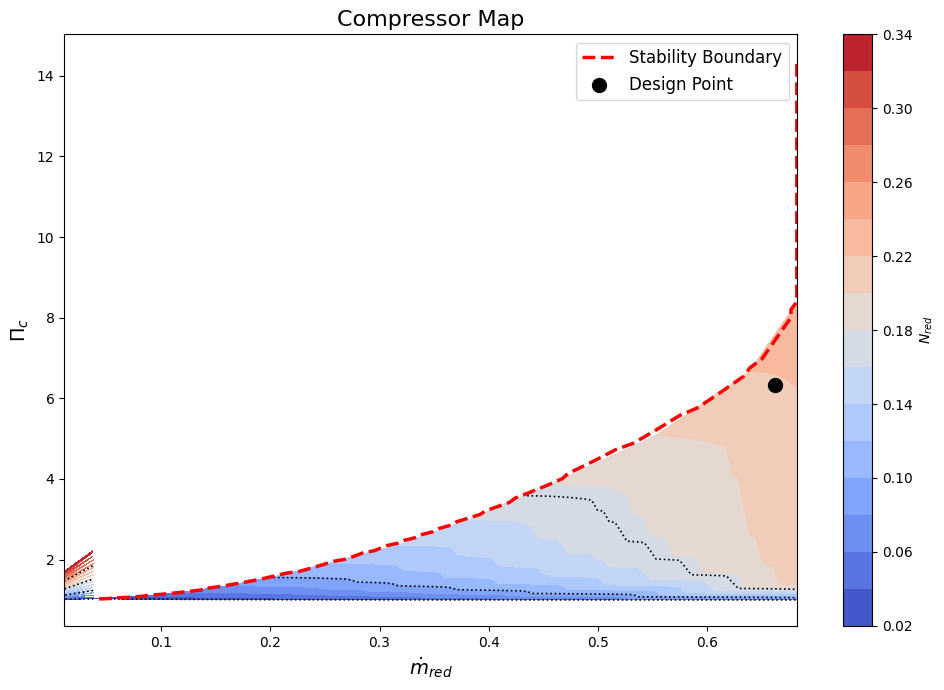

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Load data
data = np.load('compressor_map_grid.npz')
Pi_grid = data['Pi_grid']
mred_grid = data['mred_grid']
nred_grid = data['nred_grid']
M, N = np.meshgrid(mred_grid, nred_grid)

# Example design point (replace with your actual values if needed)
mred_des = 0.662714
Pi_des = 6.32846

# Find stability boundary (max Pi_c for each N_red)
max_indices = np.nanargmax(Pi_grid, axis=1)
mred_boundary = mred_grid[max_indices]
pi_max_boundary = Pi_grid[np.arange(len(nred_grid)), max_indices]

# Interpolate boundary over mred_grid
boundary_interp = interp1d(mred_boundary, pi_max_boundary, kind='linear', bounds_error=False, fill_value=np.nan)
pi_max_interp = boundary_interp(mred_grid)

# Mask Pi_grid above the interpolated boundary
mask = Pi_grid > pi_max_interp[None, :]
Pi_grid_masked = Pi_grid.copy()
Pi_grid_masked[mask] = np.nan

# Plot
plt.figure(figsize=(10, 7))
cp = plt.contourf(M, Pi_grid_masked, N, levels=16, cmap='coolwarm')
cbar = plt.colorbar(cp, label='$N_{red}$')

# Contour lines and labels for N_red
levels_to_label = np.linspace(np.nanmin(N), np.nanmax(N), 5)
contour_N = plt.contour(M, Pi_grid_masked, N, levels=levels_to_label, colors='black', linewidths=1.2, linestyles='dotted')
plt.clabel(contour_N, fmt="N = %.2f", colors='black', fontsize=12, inline_spacing=5, manual=True)

# Plot stability boundary
plt.plot(mred_boundary, pi_max_boundary, 'r--', label='Stability Boundary', linewidth=2.5)

# Plot design point
plt.scatter(mred_des, Pi_des, color='black', marker='o', s=100, label='Design Point', zorder=5)

# (Optional) Plot choked points if you have them
# choked_points = np.array([...])  # shape (n_points, 3): columns are mred, nred, pi_c
# plt.scatter(choked_points[:,0], choked_points[:,2], c='orange', marker='x', label='Choked Points', zorder=5)

plt.xlabel(r'$\dot{m}_{red}$', fontsize=14)
plt.ylabel(r'$\Pi_c$', fontsize=14)
plt.title('Compressor Map', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()